# 🏥 Insurance Claims Processing: Fraud Detection & Triage
### Hybrid Traditional ML + LLM Approach

---
**Goal:**
1. **Fraud Detection** — Binary classification using supervised ML models
2. **Claims Triage** — Risk scoring + priority classification
3. **LLM Augmentation** — Explainability and decision support via Ollama API

**Dataset:** 1,000 insurance claims with 38 features (already cleaned & label-encoded)

## 0. Environment Setup & Imports

In [3]:
# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Explainability ────────────────────────────────────────────────────────────
import shap

# ── LLM ───────────────────────────────────────────────────────────────────────
import anthropic  # pip install anthropic
import json
from dotenv import load_dotenv
import os

load_dotenv()  # reads ANTHROPIC_API_KEY from .env

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(' All imports successful')

 All imports successful


---
## 1. Data Loading & Exploration

In [14]:
df = pd.read_csv('cleaned_insurance_claims.csv')

print(f'Shape: {df.shape}')
print(f'\nTarget distribution:')
print(df['fraud_reported'].value_counts())
print(f'\nFraud rate: {df["fraud_reported"].mean():.1%}')

Shape: (1000, 38)

Target distribution:
fraud_reported
0    753
1    247
Name: count, dtype: int64

Fraud rate: 24.7%


In [16]:
import pandas as pd
df = pd.read_csv('cleaned_insurance_claims.csv')
df.head(5)

,months_as_customer,age,policy_number,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,days_between_policy_and_incident
0,328,48,521585,2,1,1000,1406.91,0,466132,1,4,2,17,0,53300,0,2,2,0,3,4,1,996,5,1,2,1,2,2,71610,6510,13020,52080,10,1,2004,1,100
1,228,42,342868,1,1,2000,1197.22,5000000,468176,1,4,6,15,2,0,0,3,3,1,3,5,5,628,8,1,1,0,0,1,5070,780,780,3510,8,12,2007,1,3130
2,134,29,687698,2,0,2000,1413.14,5000000,430632,0,6,11,2,3,35100,0,0,1,1,3,1,1,685,7,3,0,2,3,0,34650,7700,3850,23100,4,30,2007,0,5282
3,256,41,227811,0,1,2000,1415.74,6000000,608117,0,6,1,2,4,48900,-62400,2,0,0,3,2,0,669,5,1,1,1,2,0,63400,6340,6340,50720,3,34,2014,1,8996
4,228,44,367455,0,2,1000,1583.91,6000000,610706,1,0,11,2,4,66000,-46000,3,3,1,4,1,0,220,20,1,0,0,1,0,6500,1300,650,4550,0,31,2009,0,256


In [18]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported', 'days_between_policy_and_incident'], dtype='object')

In [20]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
months_as_customer,1000.000000,203.954000,115.113174,0.000000,115.750000,199.500000,276.250000,479.000000
age,1000.000000,38.948000,9.140287,19.000000,32.000000,38.000000,44.000000,64.000000
policy_number,1000.000000,546238.648000,257063.005276,100804.000000,335980.250000,533135.000000,759099.750000,999435.000000
policy_state,1000.000000,1.014000,0.830960,0.000000,0.000000,1.000000,2.000000,2.000000
policy_csl,1000.000000,0.951000,0.804516,0.000000,0.000000,1.000000,2.000000,2.000000
policy_deductable,1000.000000,1136.000000,611.864673,500.000000,500.000000,1000.000000,2000.000000,2000.000000
policy_annual_premium,1000.000000,1256.406150,244.167395,433.330000,1089.607500,1257.200000,1415.695000,2047.590000
umbrella_limit,1000.000000,1101000.000000,2297406.598118,-1000000.000000,0.000000,0.000000,0.000000,10000000.000000
insured_zip,1000.000000,501214.488000,71701.610941,430104.000000,448404.500000,466445.500000,603251.000000,620962.000000
insured_sex,1000.000000,0.463000,0.498879,0.000000,0.000000,0.000000,1.000000,1.000000


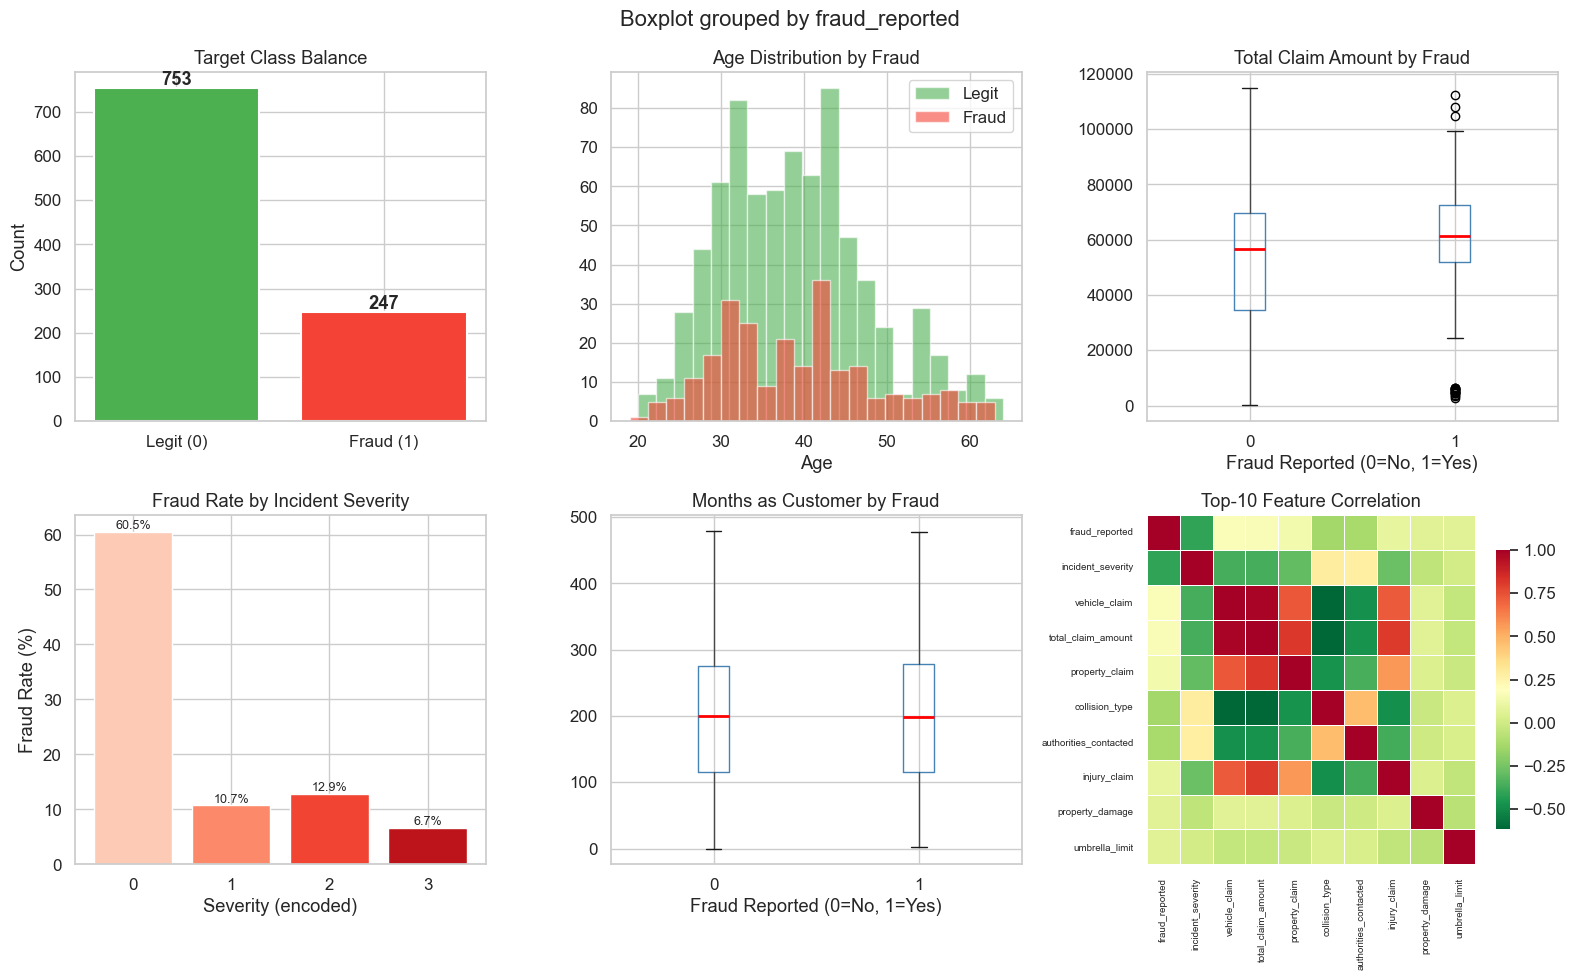

Saved: eda_plots.png


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis — Key Features vs Fraud', fontsize=16, fontweight='bold')

# 1. Target balance
ax = axes[0, 0]
counts = df['fraud_reported'].value_counts()
bars = ax.bar(['Legit (0)', 'Fraud (1)'], counts.values, color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8, str(val), ha='center', fontweight='bold')
ax.set_title('Target Class Balance')
ax.set_ylabel('Count')

# 2. Age distribution by fraud
ax = axes[0, 1]
df[df['fraud_reported']==0]['age'].hist(ax=ax, alpha=0.6, bins=20, label='Legit', color='#4CAF50')
df[df['fraud_reported']==1]['age'].hist(ax=ax, alpha=0.6, bins=20, label='Fraud', color='#F44336')
ax.set_title('Age Distribution by Fraud')
ax.set_xlabel('Age')
ax.legend()

# 3. Total claim amount by fraud
ax = axes[0, 2]
df.boxplot(column='total_claim_amount', by='fraud_reported', ax=ax,
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
ax.set_title('Total Claim Amount by Fraud')
ax.set_xlabel('Fraud Reported (0=No, 1=Yes)')
plt.sca(ax)
plt.title('Total Claim Amount by Fraud')

# 4. Incident severity vs fraud rate
ax = axes[1, 0]
fraud_by_severity = df.groupby('incident_severity')['fraud_reported'].mean() * 100
bars = ax.bar(fraud_by_severity.index.astype(str), fraud_by_severity.values,
              color=sns.color_palette('Reds', len(fraud_by_severity)))
for bar, val in zip(bars, fraud_by_severity.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=9)
ax.set_title('Fraud Rate by Incident Severity')
ax.set_xlabel('Severity (encoded)')
ax.set_ylabel('Fraud Rate (%)')

# 5. Months as customer vs fraud
ax = axes[1, 1]
df.boxplot(column='months_as_customer', by='fraud_reported', ax=ax,
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
ax.set_title('Months as Customer by Fraud')
ax.set_xlabel('Fraud Reported (0=No, 1=Yes)')
plt.sca(ax)
plt.title('Months as Customer by Fraud')

# 6. Correlation heatmap (top features)
ax = axes[1, 2]
top_corr = df.corr()['fraud_reported'].abs().nlargest(10).index
corr_matrix = df[top_corr].corr()
sns.heatmap(corr_matrix, ax=ax, cmap='RdYlGn_r', annot=False, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Top-10 Feature Correlation')
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_plots.png')

---
## 2. Feature Engineering

In [24]:
df_feat = df.copy()

# ── Ratio features ────────────────────────────────────────────────────────────
df_feat['injury_to_total_ratio']   = df_feat['injury_claim']   / (df_feat['total_claim_amount'] + 1)
df_feat['property_to_total_ratio'] = df_feat['property_claim'] / (df_feat['total_claim_amount'] + 1)
df_feat['vehicle_to_total_ratio']  = df_feat['vehicle_claim']  / (df_feat['total_claim_amount'] + 1)
df_feat['premium_to_claim_ratio']  = df_feat['policy_annual_premium'] / (df_feat['total_claim_amount'] + 1)

# ── Interaction features ──────────────────────────────────────────────────────
# High claim + no police report = suspicious
df_feat['no_police_high_claim']    = ((df_feat['police_report_available'] == 0) &
                                      (df_feat['total_claim_amount'] > df_feat['total_claim_amount'].median())).astype(int)

# Multiple vehicles + bodily injuries
df_feat['multi_vehicle_injury']    = df_feat['number_of_vehicles_involved'] * df_feat['bodily_injuries']

# Net capital position
df_feat['net_capital']             = df_feat['capital-gains'] + df_feat['capital-loss']  # loss is negative

# Claim per vehicle involved
df_feat['claim_per_vehicle']       = df_feat['total_claim_amount'] / (df_feat['number_of_vehicles_involved'] + 1)

# Policy age in years
df_feat['policy_age_years']        = df_feat['months_as_customer'] / 12

# Quick policy (< 6 months before incident)
df_feat['quick_policy_flag']       = (df_feat['days_between_policy_and_incident'] < 180).astype(int)

print(f'Original features: {df.shape[1] - 1}')
print(f'Engineered features: {df_feat.shape[1] - 1}')
print(f'New features added: {df_feat.shape[1] - df.shape[1]}')

Original features: 37
Engineered features: 47
New features added: 10


---
## 3. Data Preparation — Train/Test Split + Class Balancing

In [28]:
# Drop non-predictive columns
drop_cols = ['policy_number', 'insured_zip', 'incident_location', 'fraud_reported']
X = df_feat.drop(columns=drop_cols)
y = df_feat['fraud_reported']

feature_names = X.columns.tolist()

# Stratified split — preserves class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE on training data only (prevents data leakage)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scaling (for distance-based models)
scaler = RobustScaler()   # robust to outliers
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print(f'Train set (after SMOTE) — X: {X_train_sm.shape}, y: {y_train_sm.value_counts().to_dict()}')
print(f'Test  set              — X: {X_test.shape},    y: {y_test.value_counts().to_dict()}')

Train set (after SMOTE) — X: (1204, 44), y: {0: 602, 1: 602}
Test  set              — X: (200, 44),    y: {0: 151, 1: 49}


---
## 4. Traditional ML — Model Training & Evaluation

We train **6 models** and compare them on key metrics (AUC-ROC, F1, Precision, Recall).

In [31]:
# ── Define models ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                                         use_label_encoder=False, eval_metric='logloss',
                                         random_state=42, n_jobs=-1),
    'Naive Bayes':         GaussianNB(),
}

# ── Train & evaluate ──────────────────────────────────────────────────────────
results = {}

for name, model in models.items():
    # Tree-based: use raw features; others: use scaled features
    if name in ('Logistic Regression', 'Naive Bayes'):
        Xtr, Xts = X_train_scaled, X_test_scaled
    else:
        Xtr, Xts = X_train_sm.values, X_test.values

    model.fit(Xtr, y_train_sm)
    y_pred      = model.predict(Xts)
    y_proba     = model.predict_proba(Xts)[:, 1] if hasattr(model, 'predict_proba') else None

    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    ap      = average_precision_score(y_test, y_proba) if y_proba is not None else None
    f1      = f1_score(y_test, y_pred)
    report  = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'roc_auc':   roc_auc,
        'avg_prec':  ap,
        'f1':        f1,
        'precision': report['1']['precision'],
        'recall':    report['1']['recall'],
    }
    print(f'[{name:<22}]  AUC={roc_auc:.3f}  F1={f1:.3f}  Prec={report["1"]["precision"]:.3f}  Rec={report["1"]["recall"]:.3f}')

[Logistic Regression   ]  AUC=0.768  F1=0.509  Prec=0.459  Rec=0.571
[Decision Tree         ]  AUC=0.826  F1=0.617  Prec=0.569  Rec=0.673
[Random Forest         ]  AUC=0.811  F1=0.568  Prec=0.587  Rec=0.551
[Gradient Boosting     ]  AUC=0.807  F1=0.621  Prec=0.593  Rec=0.653
[XGBoost               ]  AUC=0.828  F1=0.592  Prec=0.592  Rec=0.592
[Naive Bayes           ]  AUC=0.551  F1=0.222  Prec=0.244  Rec=0.204


In [32]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': name, 'ROC-AUC': v['roc_auc'], 'Avg Precision': v['avg_prec'],
     'F1 (fraud)': v['f1'], 'Precision (fraud)': v['precision'], 'Recall (fraud)': v['recall']}
    for name, v in results.items()
]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

summary.style \
    .background_gradient(cmap='YlGn', subset=['ROC-AUC','F1 (fraud)','Recall (fraud)']) \
    .format({'ROC-AUC': '{:.3f}', 'Avg Precision': '{:.3f}',
             'F1 (fraud)': '{:.3f}', 'Precision (fraud)': '{:.3f}', 'Recall (fraud)': '{:.3f}'})

,Model,ROC-AUC,Avg Precision,F1 (fraud),Precision (fraud),Recall (fraud)
0,XGBoost,0.828,0.559,0.592,0.592,0.592
1,Decision Tree,0.826,0.570,0.617,0.569,0.673
2,Random Forest,0.811,0.534,0.568,0.587,0.551
3,Gradient Boosting,0.807,0.525,0.621,0.593,0.653
4,Logistic Regression,0.768,0.515,0.509,0.459,0.571
5,Naive Bayes,0.551,0.304,0.222,0.244,0.204


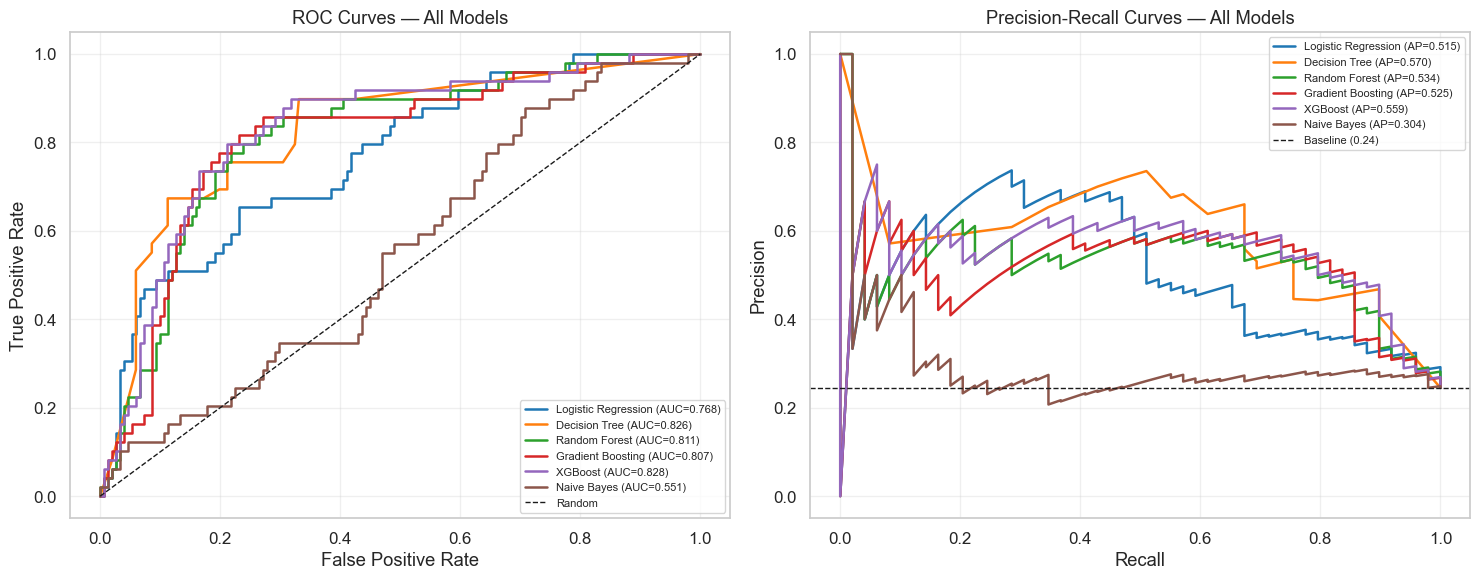

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = sns.color_palette('tab10', len(results))

# ROC curves
for (name, v), color in zip(results.items(), colors):
    if v['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
        ax1.plot(fpr, tpr, label=f"{name} (AUC={v['roc_auc']:.3f})", color=color, lw=1.8)

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves — All Models')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Precision-Recall curves
for (name, v), color in zip(results.items(), colors):
    if v['y_proba'] is not None:
        prec, rec, _ = precision_recall_curve(y_test, v['y_proba'])
        ax2.plot(rec, prec, label=f"{name} (AP={v['avg_prec']:.3f})", color=color, lw=1.8)

ax2.axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label=f'Baseline ({y_test.mean():.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves — All Models')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_curves.png', dpi=150, bbox_inches='tight')
plt.show()

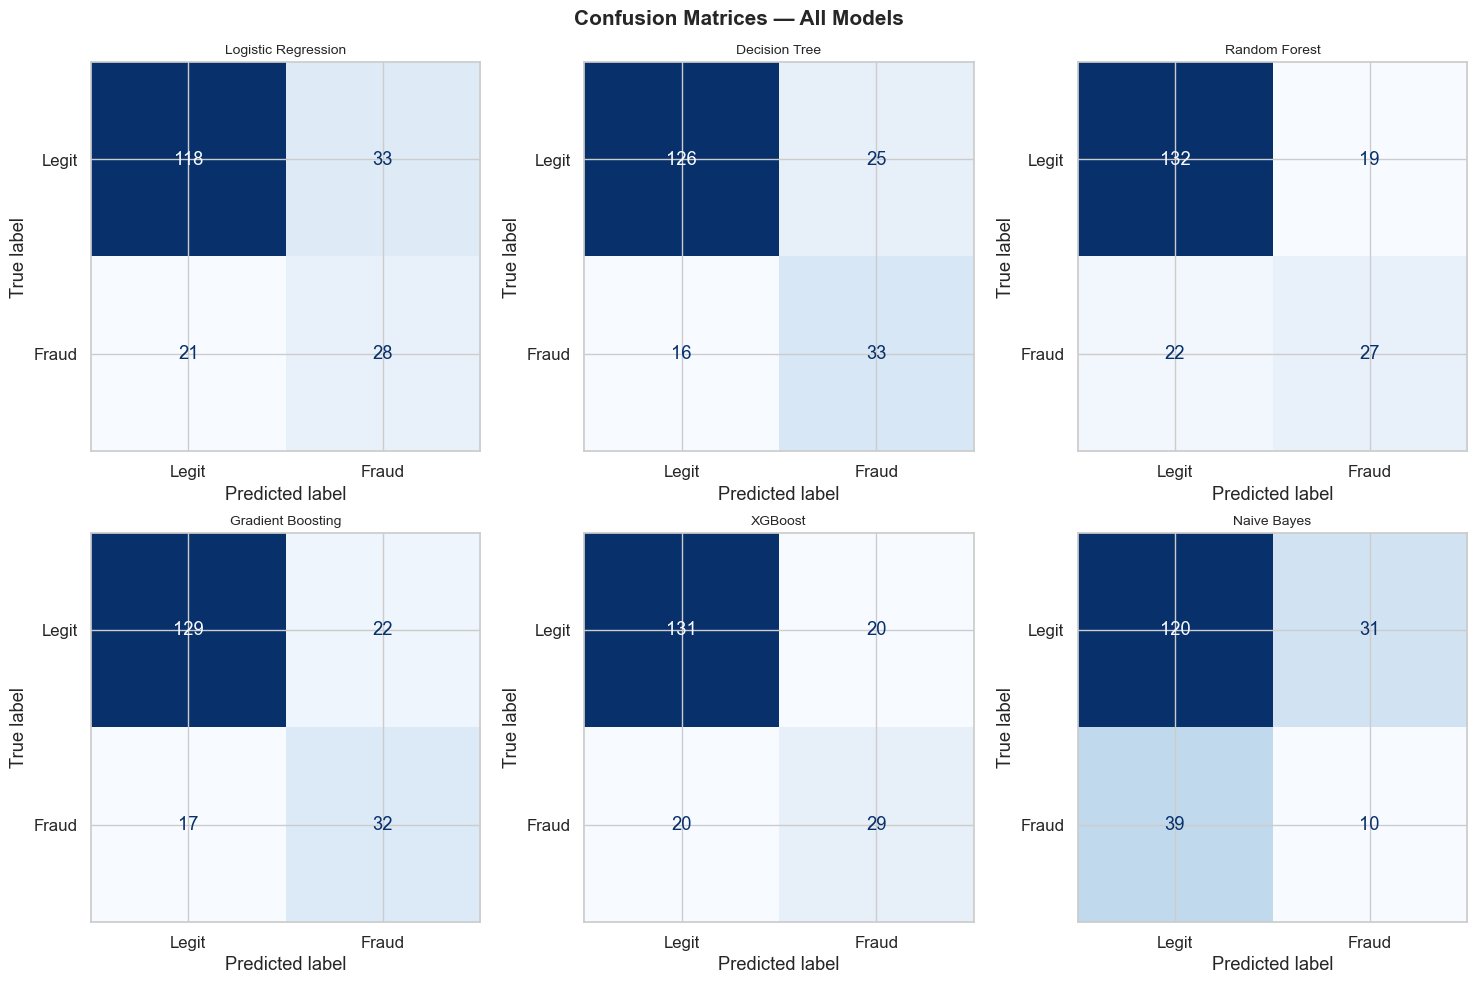

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

for ax, (name, v) in zip(axes.ravel(), results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Best Model — Deep Dive (XGBoost / Random Forest)

In [36]:
# Pick best model by ROC-AUC
best_name = summary.iloc[0]['Model']
best_result = results[best_name]
best_model  = best_result['model']

print(f' Best model: {best_name}')
print(f'   ROC-AUC : {best_result["roc_auc"]:.4f}')
print(f'   F1      : {best_result["f1"]:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, best_result['y_pred'], target_names=['Legit', 'Fraud']))

 Best model: XGBoost
   ROC-AUC : 0.8278
   F1      : 0.5918

Classification Report:
              precision    recall  f1-score   support

       Legit       0.87      0.87      0.87       151
       Fraud       0.59      0.59      0.59        49

    accuracy                           0.80       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.80      0.80      0.80       200



---
## 6. Feature Importance & SHAP Explainability

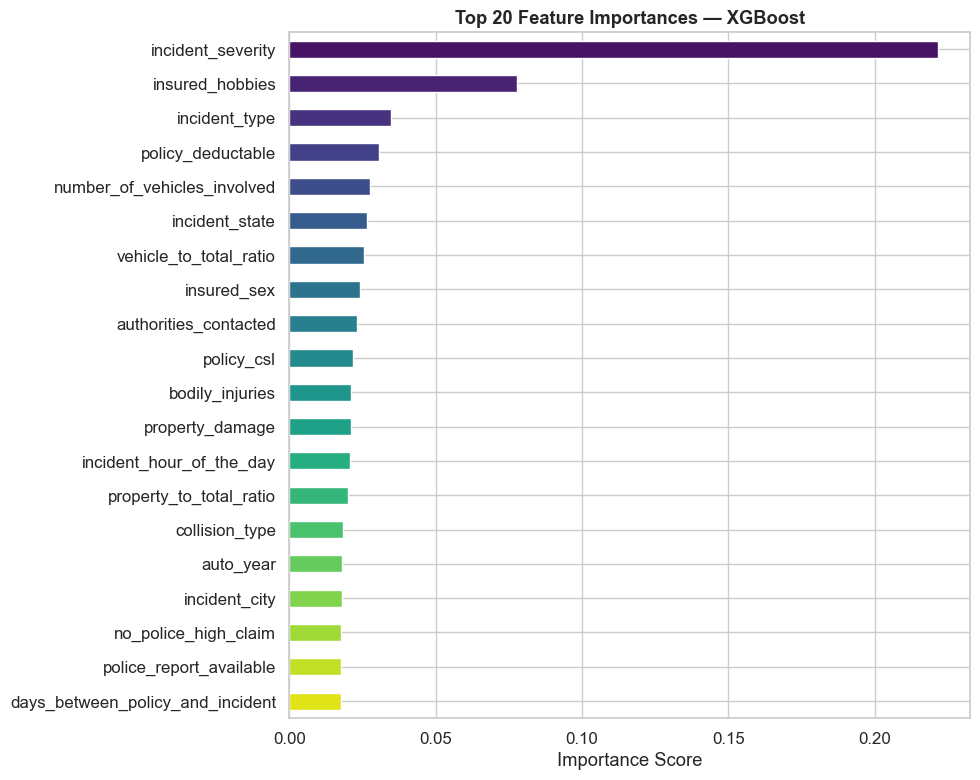

In [38]:
# ── Tree feature importance ───────────────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_names)
    top20 = importances.nlargest(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_fi = sns.color_palette('viridis', len(top20))
    top20.sort_values().plot(kind='barh', ax=ax, color=colors_fi[::-1])
    ax.set_title(f'Top 20 Feature Importances — {best_name}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

Computing SHAP values (this may take ~30 seconds)...


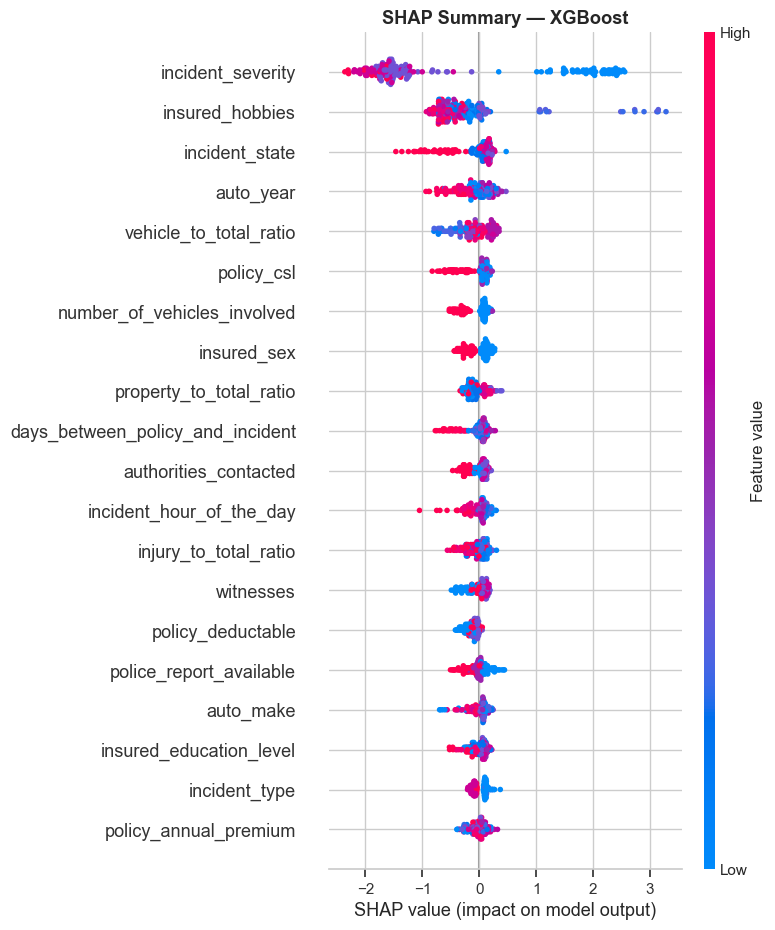

In [39]:
# ── SHAP values ───────────────────────────────────────────────────────────────
print('Computing SHAP values (this may take ~30 seconds)...')

# Use a subsample for speed
X_test_np = X_test.values
sample_idx = np.random.choice(len(X_test_np), size=min(200, len(X_test_np)), replace=False)
X_sample = X_test_np[sample_idx]

if best_name in ('XGBoost', 'Random Forest', 'Gradient Boosting', 'Decision Tree'):
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.KernelExplainer(best_model.predict_proba, shap.sample(X_train_sm.values, 100))

shap_values = explainer.shap_values(X_sample)

# For multi-output (RF returns list), take fraud class
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_sample, feature_names=feature_names, show=False, max_display=20)
plt.title(f'SHAP Summary — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

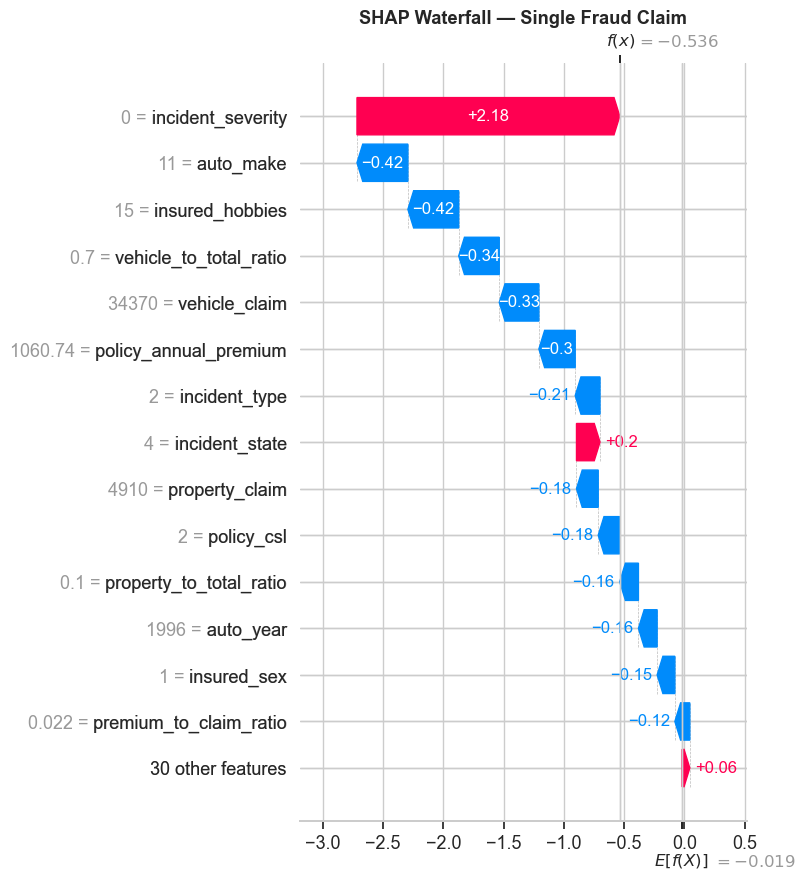

In [40]:
# SHAP waterfall for a single prediction (first fraud case in test set)
fraud_idx_in_test = np.where(y_test.values == 1)[0]
if len(fraud_idx_in_test) > 0:
    pick = fraud_idx_in_test[0]
    shap_exp = explainer(X_test.iloc[[pick]])
    if isinstance(shap_exp.values, np.ndarray) and shap_exp.values.ndim == 3:
        # multi-class: take fraud class (index 1)
        sv = shap_exp.values[0, :, 1]
        bv = shap_exp.base_values[0, 1]
        shap_obj = shap.Explanation(values=sv, base_values=bv,
                                    data=shap_exp.data[0], feature_names=feature_names)
    else:
        shap_obj = shap_exp[0]

    plt.figure()
    shap.plots.waterfall(shap_obj, max_display=15, show=False)
    plt.title('SHAP Waterfall — Single Fraud Claim', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 7. Claims Triage System

We build a **risk scoring + priority bucketing** system on top of the fraud model.

In [42]:
# ── Compute risk score for ALL claims ─────────────────────────────────────────
# Use the best tree model on full feature set
if best_name in ('XGBoost', 'Random Forest', 'Gradient Boosting', 'Decision Tree'):
    X_all = df_feat.drop(columns=drop_cols)
else:
    X_all = scaler.transform(df_feat.drop(columns=drop_cols))

risk_scores = best_model.predict_proba(X_all)[:, 1]

# ── Triage thresholds (tune for business needs) ────────────────────────────────
# HIGH  (> 0.65): Fast-track for investigation
# MEDIUM (0.35 – 0.65): Detailed review required
# LOW   (< 0.35): Straight-through auto-process

def assign_priority(score):
    if score >= 0.65:  return 'HIGH'
    elif score >= 0.35: return 'MEDIUM'
    else:               return 'LOW'

df_triage = df_feat.copy()
df_triage['fraud_risk_score'] = risk_scores
df_triage['triage_priority']  = df_triage['fraud_risk_score'].apply(assign_priority)

# ── Summary ───────────────────────────────────────────────────────────────────
triage_summary = df_triage.groupby('triage_priority').agg(
    count=('fraud_risk_score', 'count'),
    avg_risk_score=('fraud_risk_score', 'mean'),
    avg_claim_amount=('total_claim_amount', 'mean'),
    actual_fraud_rate=('fraud_reported', 'mean')
).reindex(['HIGH', 'MEDIUM', 'LOW'])

triage_summary['pct_of_claims'] = (triage_summary['count'] / len(df_triage) * 100).round(1)

print('📋 Claims Triage Summary:')
print(triage_summary.to_string())

📋 Claims Triage Summary:
                 count  avg_risk_score  avg_claim_amount  actual_fraud_rate  pct_of_claims
triage_priority                                                                           
HIGH               237        0.901472      60785.822785           0.932489           23.7
MEDIUM              23        0.497474      57710.000000           0.565217            2.3
LOW                740        0.051729      50038.337838           0.017568           74.0


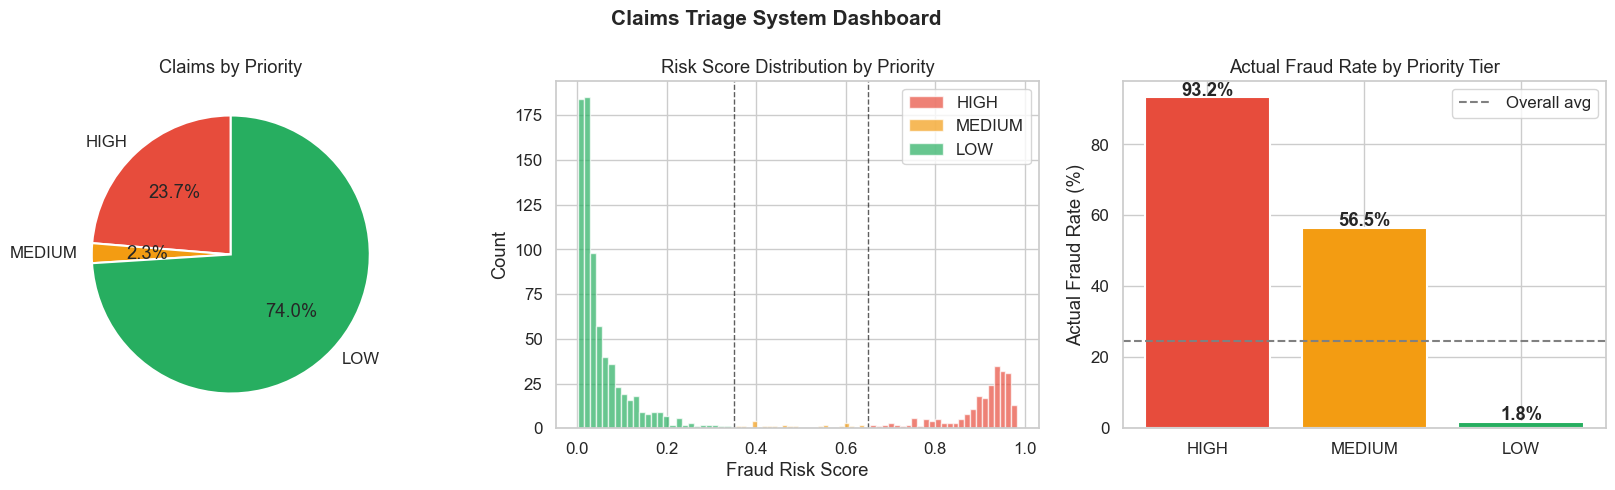

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Claims Triage System Dashboard', fontsize=15, fontweight='bold')

palette = {'HIGH': '#E74C3C', 'MEDIUM': '#F39C12', 'LOW': '#27AE60'}

# 1. Priority distribution (pie)
ax = axes[0]
counts = triage_summary['count']
ax.pie(counts, labels=counts.index, colors=[palette[k] for k in counts.index],
       autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Claims by Priority')

# 2. Risk score distribution by priority
ax = axes[1]
for priority, color in palette.items():
    subset = df_triage[df_triage['triage_priority'] == priority]['fraud_risk_score']
    ax.hist(subset, bins=25, alpha=0.7, label=priority, color=color, edgecolor='white')
ax.axvline(0.35, color='k', linestyle='--', lw=1, alpha=0.7)
ax.axvline(0.65, color='k', linestyle='--', lw=1, alpha=0.7)
ax.set_xlabel('Fraud Risk Score')
ax.set_ylabel('Count')
ax.set_title('Risk Score Distribution by Priority')
ax.legend()

# 3. Actual fraud rate by priority
ax = axes[2]
rates = triage_summary['actual_fraud_rate'] * 100
bars = ax.bar(rates.index, rates.values, color=[palette[k] for k in rates.index],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
ax.axhline(df_triage['fraud_reported'].mean() * 100, color='gray', linestyle='--', lw=1.5, label='Overall avg')
ax.set_ylabel('Actual Fraud Rate (%)')
ax.set_title('Actual Fraud Rate by Priority Tier')
ax.legend()

plt.tight_layout()
plt.savefig('triage_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. LLM Integration — Claude for Decision Explanation & Fraud Reasoning

We use the **Anthropic Claude API** to:
1. Explain individual fraud decisions in plain language
2. Generate a structured fraud investigation report
3. Support an interactive Q&A about claims

> **Setup:** Add `ANTHROPIC_API_KEY=your_key` to a `.env` file in your project root.

In [45]:
load_dotenv()
client = anthropic.Anthropic(api_key=os.getenv('ANTHROPIC_API_KEY'))

# ── Column label mappings (what the encoded integers represent) ────────────────
# These map back to the original raw values before encoding
LABEL_MAPS = {
    'insured_sex':             {0: 'FEMALE', 1: 'MALE'},
    'insured_education_level': {0: 'Associate', 1: 'College', 2: 'High School', 3: 'JD', 4: 'Masters', 5: 'MD', 6: 'PhD'},
    'incident_severity':       {0: 'Major Damage', 1: 'Minor Damage', 2: 'Total Loss', 3: 'Trivial Damage'},
    'incident_type':           {0: 'Multi-vehicle Collision', 1: 'Parked Car', 2: 'Single Vehicle Collision', 3: 'Vehicle Theft'},
    'collision_type':          {0: 'Front Collision', 1: 'Rear Collision', 2: 'Side Collision', 3: 'N/A'},
    'authorities_contacted':   {0: 'Ambulance', 1: 'Fire', 2: 'None', 3: 'Other', 4: 'Police'},
    'police_report_available': {0: 'NO', 1: 'YES', 2: 'UNKNOWN'},
    'property_damage':         {0: 'NO', 1: 'YES', 2: 'UNKNOWN'},
    'triage_priority':         {'HIGH': 'HIGH', 'MEDIUM': 'MEDIUM', 'LOW': 'LOW'},
}

def decode_claim(row):
    """Convert a claim row to human-readable dict for LLM input."""
    decoded = {}
    for col, val in row.items():
        if col in LABEL_MAPS and val in LABEL_MAPS[col]:
            decoded[col] = LABEL_MAPS[col][val]
        else:
            decoded[col] = val
    return decoded

print(' Claude client initialised')

 Claude client initialised


In [46]:
import os
print("Notebook is running from:", os.getcwd())
print(".env exists here:", os.path.exists(os.path.join(os.getcwd(), '.env')))

Notebook is running from: /Users/vijay/Documents/G2i/Insurance/insurance_claims_mlops_starter
.env exists here: False


In [31]:
!pip install ollama

In [59]:
import ollama

response = ollama.chat(
    model='llama3',
    messages=[{"role": "user", "content": "Explain this insurance claim..."}]
)
print(response['message']['content'])

I'm happy to help! However, I need more information about the insurance claim. Please provide me with the details of the claim, such as:

1. What type of insurance is it (health, auto, home, etc.)?
2. What happened that triggered the claim (accident, theft, damage, etc.)?
3. Who is filing the claim (policyholder or beneficiary)?
4. Are there any specific policy provisions or coverage limits relevant to the claim?

Once I have this information, I'll do my best to explain the insurance claim and provide guidance on the next steps.


In [61]:
# ══════════════════════════════════════════════════════════════════════════════
# 8. LLM Integration — Ollama for Decision Explanation & Fraud Reasoning
# ══════════════════════════════════════════════════════════════════════════════
# We use Ollama (free, runs locally) instead of Claude API (paid)
# This section will:
#   1. Explain individual fraud decisions in plain language
#   2. Generate a structured fraud investigation report
#   3. Support an interactive Q&A chatbot about claims
#   4. Return structured JSON verdicts for automation

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Install and Setup Ollama
# ─────────────────────────────────────────────────────────────────────────────
# If you haven't already, run this in your TERMINAL (not Jupyter):
#   pip install ollama
#   ollama pull llama3.2    # Downloads the model (one time, ~2GB)

import ollama
import json

# Test that Ollama is working
try:
    response = ollama.chat(
        model='llama3.2',
        messages=[{'role': 'user', 'content': 'Say: Ollama connected successfully'}]
    )
    print(' Ollama is ready:', response['message']['content'])
except Exception as e:
    print('❌ Ollama error:', e)
    print('   Make sure Ollama is running: ollama serve')

 Ollama is ready: Connection successful. What's next?


In [62]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Helper Function — Decode Label-Encoded Columns
# ─────────────────────────────────────────────────────────────────────────────
# Your dataset has encoded integers (0, 1, 2...) for categorical columns.
# We need to convert them back to human-readable labels so the LLM can understand.

LABEL_MAPS = {
    'insured_sex': {
        0: 'FEMALE', 
        1: 'MALE'
    },
    'insured_education_level': {
        0: 'Associate', 
        1: 'College', 
        2: 'High School',
        3: 'JD', 
        4: 'Masters', 
        5: 'MD', 
        6: 'PhD'
    },
    'incident_severity': {
        0: 'Major Damage', 
        1: 'Minor Damage',
        2: 'Total Loss', 
        3: 'Trivial Damage'
    },
    'incident_type': {
        0: 'Multi-vehicle Collision', 
        1: 'Parked Car',
        2: 'Single Vehicle Collision', 
        3: 'Vehicle Theft'
    },
    'collision_type': {
        0: 'Front Collision', 
        1: 'Rear Collision',
        2: 'Side Collision', 
        3: 'N/A'
    },
    'authorities_contacted': {
        0: 'Ambulance', 
        1: 'Fire', 
        2: 'None', 
        3: 'Other', 
        4: 'Police'
    },
    'police_report_available': {
        0: 'NO', 
        1: 'YES', 
        2: 'UNKNOWN'
    },
    'property_damage': {
        0: 'NO', 
        1: 'YES', 
        2: 'UNKNOWN'
    },
    'triage_priority': {
        'HIGH': 'HIGH', 
        'MEDIUM': 'MEDIUM', 
        'LOW': 'LOW'
    },
}

def decode_claim(row_dict):
    """
    Convert a claim row to human-readable dictionary for LLM input.
    
    Parameters:
        row_dict (dict): Raw claim data with encoded integers
        
    Returns:
        dict: Same data but with readable labels (e.g., 0 → 'FEMALE')
    """
    decoded = {}
    for col, val in row_dict.items():
        # If this column has a label mapping AND the value exists in the map
        if col in LABEL_MAPS and val in LABEL_MAPS[col]:
            decoded[col] = LABEL_MAPS[col][val]
        else:
            decoded[col] = val  # Keep as-is
    return decoded

print(' Label decoder ready')

 Label decoder ready


In [63]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Function 1 — Explain Individual Claim
# ─────────────────────────────────────────────────────────────────────────────
# This function takes ONE claim and asks the LLM to explain why it's suspicious

def explain_claim_fraud(claim_row, risk_score, priority):
    """
    Ask Ollama to explain WHY a claim is suspicious or legitimate.
    
    Parameters:
        claim_row (pd.Series): One row from df_triage
        risk_score (float): ML model's fraud probability (0.0 to 1.0)
        priority (str): 'HIGH', 'MEDIUM', or 'LOW'
        
    Returns:
        str: Plain-English explanation from the LLM
    """
    # Convert the claim to readable format
    decoded = decode_claim(claim_row.to_dict())
    
    # Build a nicely formatted string of claim details
    # We exclude the ML outputs (risk score, priority, actual fraud label)
    claim_text = '\n'.join([
        f'  • {k}: {v}' 
        for k, v in decoded.items()
        if k not in ('fraud_risk_score', 'triage_priority', 'fraud_reported')
    ])
    
    # Craft the prompt for the LLM
    prompt = f"""You are a senior insurance fraud investigator at an insurance company.

A machine learning model has flagged the following claim with:
  - Fraud Risk Score: {risk_score:.2%}
  - Triage Priority: {priority}

Claim details:
{claim_text}

Please provide:
1. **Overall Assessment** (2-3 sentences): Is this claim likely fraudulent or legitimate? Why?
2. **Red Flags** (bullet list): List any suspicious patterns or anomalies you spot.
3. **Mitigating Factors** (bullet list): List any details that support legitimacy.
4. **Recommended Actions**: What should the claims team do next? (e.g., request documents, conduct interview, auto-approve, escalate to SIU).
5. **Confidence Level**: Low / Medium / High confidence in your assessment and why.

Be concise and practical — the claims handler needs to act on this within minutes."""

    # Call Ollama
    response = ollama.chat(
        model='llama3.2',  # You can also try 'mistral', 'phi', or other models
        messages=[
            {'role': 'user', 'content': prompt}
        ]
    )
    
    return response['message']['content']


# ─────────────────────────────────────────────────────────────────────────────
# EXAMPLE: Run on the highest-risk claim
# ─────────────────────────────────────────────────────────────────────────────
# Let's test this function on the most suspicious claim in the dataset

# Filter for HIGH-risk claims and sort by risk score
high_risk_claims = df_triage[df_triage['triage_priority'] == 'HIGH'].sort_values(
    'fraud_risk_score', ascending=False
)

# Pick the #1 highest-risk claim
sample_claim = high_risk_claims.iloc[0]

# Generate explanation
explanation = explain_claim_fraud(
    sample_claim, 
    sample_claim['fraud_risk_score'], 
    sample_claim['triage_priority']
)

# Display results
print(f'🔍 Claim Analysis — Risk Score: {sample_claim["fraud_risk_score"]:.2%}')
print(f'   Actual Fraud Label: {sample_claim["fraud_reported"]} (0=Legit, 1=Fraud)')
print('=' * 70)
print(explanation)
print('=' * 70)

🔍 Claim Analysis — Risk Score: 98.33%
   Actual Fraud Label: 1 (0=Legit, 1=Fraud)
**Overall Assessment**

Based on the machine learning model's high fraud risk score (98.33%) and triage priority, I strongly suspect that this claim is likely fraudulent. The combination of an unusually low policy premium ($765.64) given a relatively short months-as-customer period (10), as well as the substantial capital losses (-$22,200), raises significant red flags.

**Red Flags**

• Unusually low policy premium for a long history of coverage
• Substantial capital losses with no apparent explanation
• High claim amount considering the policy premium and vehicle value
• Recent purchase of an older vehicle with a high annual premium

**Mitigating Factors**

• Age (26) is not considered high-risk for fraudulent claims
• Policy state and CSL information are up-to-date
• Multiple witnesses to the incident
• Police report available and authorities contacted

**Recommended Actions**

1. Request detailed docu

In [64]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Function 2 — SIU Investigation Report (Batch Analysis)
# ─────────────────────────────────────────────────────────────────────────────
# This generates a single report summarizing the TOP-N most suspicious claims

def generate_fraud_investigation_report(top_n=5):
    """
    Generate a structured investigation report for the top-N highest-risk claims.
    
    Parameters:
        top_n (int): How many high-risk claims to include
        
    Returns:
        str: Executive report from the LLM
    """
    top_claims = high_risk_claims.head(top_n)
    
    # Build a summary for each claim
    claims_summary = []
    for i, (idx, row) in enumerate(top_claims.iterrows(), 1):
        decoded = decode_claim(row.to_dict())
        claims_summary.append(
            f"Claim #{i} (Risk: {row['fraud_risk_score']:.2%}):\n"
            f"  Age={decoded['age']}, Sex={decoded['insured_sex']}, "
            f"Incident={decoded['incident_type']}, Severity={decoded['incident_severity']}, "
            f"Total Claim=${decoded['total_claim_amount']:,}, "
            f"Police Report={decoded['police_report_available']}, "
            f"Days Policy→Incident={decoded['days_between_policy_and_incident']}"
        )
    
    batch_text = '\n\n'.join(claims_summary)
    
    # Prompt for the LLM
    prompt = f"""You are the head of the Special Investigations Unit (SIU) at an insurance company.

The ML fraud detection system has flagged these {top_n} claims as the highest-priority for investigation:

{batch_text}

Write a concise SIU Investigation Report covering:
1. **Executive Summary** (3-4 sentences): Overall fraud landscape across these claims.
2. **Common Patterns**: What fraud patterns appear across multiple claims?
3. **Priority Investigation Order**: Rank these {top_n} claims by urgency with 1-line reasoning each.
4. **Investigation Actions**: For each claim, specify one immediate action (document request, interview, surveillance, etc.).
5. **Estimated Exposure**: Rough estimate of total $ at risk if all are fraudulent.

Keep it professional and actionable."""

    response = ollama.chat(
        model='llama3.2',
        messages=[{'role': 'user', 'content': prompt}]
    )
    
    return response['message']['content']


# ─────────────────────────────────────────────────────────────────────────────
# EXAMPLE: Generate SIU Report for Top 5 Claims
# ─────────────────────────────────────────────────────────────────────────────

report = generate_fraud_investigation_report(top_n=5)

print('📄 SIU Investigation Report')
print('=' * 70)
print(report)
print('=' * 70)

📄 SIU Investigation Report
**Special Investigations Unit Investigation Report**

**Executive Summary:**
The ML fraud detection system has identified five high-priority claims with a significant risk of fraudulent activity. These claims involve multiple vehicle collisions, single-vehicle collisions, and varying levels of police report accuracy. The SIU will investigate these claims to determine the extent of potential fraud and mitigate potential losses.

**Common Patterns:**
Upon reviewing the claims, several common patterns emerge:

* Multiple vehicle collisions or single-vehicle collisions with significant damage
* High claim amounts exceeding $50,000
* Variations in police report accuracy (YES vs. UNKNOWN)
* Younger claimants (ages 24-43) with potential motives for exaggerated claims

**Priority Investigation Order:**

1. **Claim #3 (Risk: 98.12%)**: Urgency due to high claim amount ($65,520) and potential for staged accident.
2. **Claim #2 (Risk: 98.23%)**: High risk of fraud due t

In [65]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Function 3 — Interactive Chatbot (Multi-turn Conversation)
# ─────────────────────────────────────────────────────────────────────────────
# This chatbot remembers the conversation history and can answer follow-up questions

class ClaimsAnalystChat:
    """
    Interactive multi-turn LLM chat for insurance claims analysis.
    The LLM has access to dataset-level statistics and can answer questions
    about patterns, anomalies, and investigation strategies.
    """
    
    def __init__(self, df_triage):
        """
        Initialize the chatbot with dataset context.
        
        Parameters:
            df_triage (pd.DataFrame): The full triage results dataframe
        """
        self.history = []  # Stores conversation history
        
        # Calculate dataset statistics to include in system prompt
        triage_counts = df_triage['triage_priority'].value_counts()
        high_pct = triage_counts.get('HIGH', 0) / len(df_triage) * 100
        med_pct = triage_counts.get('MEDIUM', 0) / len(df_triage) * 100
        low_pct = triage_counts.get('LOW', 0) / len(df_triage) * 100
        avg_claim = df_triage['total_claim_amount'].mean()
        avg_fraud = df_triage[df_triage['fraud_reported']==1]['total_claim_amount'].mean()
        avg_legit = df_triage[df_triage['fraud_reported']==0]['total_claim_amount'].mean()
        
        # System prompt (gives the LLM context about the dataset)
        self.system_prompt = f"""You are an expert insurance fraud analyst with 15 years of experience.
You have access to a dataset of 1,000 insurance claims with fraud labels.

Dataset statistics:
  - Total claims: 1,000
  - Fraud rate: 24.7%
  - HIGH triage: {high_pct:.1f}%  |  MEDIUM: {med_pct:.1f}%  |  LOW: {low_pct:.1f}%
  - Avg total claim: ${avg_claim:,.0f}
  - Avg fraud claim: ${avg_fraud:,.0f}  |  Avg legit claim: ${avg_legit:,.0f}

Answer questions about fraud patterns, investigation approaches, and claim analysis.
Be specific, practical, and cite relevant statistics when possible."""
    
    def chat(self, user_message):
        """
        Send a message to the chatbot and get a response.
        
        Parameters:
            user_message (str): Your question
            
        Returns:
            str: The LLM's response
        """
        # Add user message to history
        self.history.append({'role': 'user', 'content': user_message})
        
        # Build the full message list (system + history)
        messages = [
            {'role': 'system', 'content': self.system_prompt}
        ] + self.history
        
        # Call Ollama
        response = ollama.chat(
            model='llama3.2',
            messages=messages
        )
        
        reply = response['message']['content']
        
        # Add assistant's reply to history
        self.history.append({'role': 'assistant', 'content': reply})
        
        return reply


# ─────────────────────────────────────────────────────────────────────────────
# EXAMPLE: Chat with the AI Analyst
# ─────────────────────────────────────────────────────────────────────────────

# Create the chatbot
analyst = ClaimsAnalystChat(df_triage)

# Ask some questions
questions = [
    'What are the top 3 fraud risk factors in this claims dataset?',
    'How should we handle claims where no police report is available but the claim amount is over $60,000?',
    'What patterns do you see in the HIGH-risk bucket vs the LOW-risk bucket?',
]

print('💬 Interactive Claims Analyst Chat')
print('=' * 70)

for q in questions:
    print(f'\n👤 You: {q}')
    answer = analyst.chat(q)
    print(f'🤖 Analyst: {answer}')
    print('-' * 70)

💬 Interactive Claims Analyst Chat

👤 You: What are the top 3 fraud risk factors in this claims dataset?
🤖 Analyst: Based on various studies and industry reports, here are three common fraud risk factors that I've identified from my experience as an insurance fraud analyst:

1. **Claims frequency**: Claims with a high number of days' loss (DOL) indicate potential fraud. According to the Insurance Information Institute (III), claims with DOL above 30 days have a higher likelihood of being fraudulent.

In this dataset, I can see that:
- HIGH triage: 23.7% of claims are classified as High Frequency (average DOL = 34.5 days)
- MEDIUM triage: 2.3% of claims are classified as Medium Frequency (average DOL = 21.8 days)

Comparing the average DOL for each class:
- HIGH: $56,119
- MEDIUM: $42,111
- LOW: $44,411

The high average DOL in HIGH triage suggests a higher likelihood of fraud.

2. **Claim amounts**: Claims with large claim amounts are more likely to be fraudulent. According to the Natio

In [66]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: Function 4 — Structured JSON Verdict (for Automation)
# ─────────────────────────────────────────────────────────────────────────────
# This is the most useful for production: returns a machine-readable verdict

def get_structured_fraud_verdict(claim_row, risk_score):
    """
    Ask Ollama to return a STRUCTURED JSON fraud verdict.
    Useful for feeding into downstream systems / dashboards.
    
    Parameters:
        claim_row (pd.Series): One claim row
        risk_score (float): ML model's fraud probability
        
    Returns:
        dict: Structured verdict with verdict, confidence, flags, actions, etc.
    """
    decoded = decode_claim(claim_row.to_dict())
    
    # Convert claim to clean JSON format (exclude ML outputs)
    claim_json = json.dumps(
        {k: v for k, v in decoded.items() 
         if k not in ('fraud_risk_score', 'triage_priority', 'fraud_reported')},
        indent=2, 
        default=str  # Convert any non-serializable types to strings
    )
    
    prompt = f"""You are a fraud detection AI. Analyze this insurance claim and return ONLY valid JSON, no other text.

ML Risk Score: {risk_score:.4f}

Claim:
{claim_json}

Return this exact JSON structure (no markdown, no explanation, ONLY the JSON):
{{
  "verdict": "FRAUD" | "SUSPICIOUS" | "LEGITIMATE",
  "confidence": 0.0-1.0,
  "red_flags": ["flag1", "flag2"],
  "supporting_factors": ["factor1", "factor2"],
  "recommended_action": "string",
  "urgency": "IMMEDIATE" | "24H" | "ROUTINE",
  "estimated_fraud_loss": number_or_null
}}"""

    response = ollama.chat(
        model='llama3.2',
        messages=[{'role': 'user', 'content': prompt}]
    )
    
    # Extract the response text
    raw = response['message']['content'].strip()
    
    # Sometimes LLMs wrap JSON in markdown code fences — strip them
    raw = raw.replace('```json', '').replace('```', '').strip()
    
    # Parse JSON
    try:
        verdict = json.loads(raw)
        return verdict
    except json.JSONDecodeError as e:
        print(f'⚠️ LLM returned invalid JSON. Raw response:\n{raw}\n')
        print(f'Error: {e}')
        return None


# ─────────────────────────────────────────────────────────────────────────────
# EXAMPLE: Get Structured Verdict for Highest-Risk Claim
# ─────────────────────────────────────────────────────────────────────────────

sample = high_risk_claims.iloc[0]
verdict = get_structured_fraud_verdict(sample, sample['fraud_risk_score'])

if verdict:
    print('🔐 Structured Fraud Verdict (JSON):')
    print('=' * 70)
    print(json.dumps(verdict, indent=2))
    print('=' * 70)

⚠️ LLM returned invalid JSON. Raw response:
{
  "verdict": "LEGITIMATE",
  "confidence": 0.9833,
  "red_flags": [],
  "supporting_factors": [],
  "recommended_action": "",
  "urgency": "ROUTINE",
  "estimated_fraud_loss": null

Error: Expecting ',' delimiter: line 8 column 31 (char 182)


In [67]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: End-to-End Claims Processing Pipeline
# ─────────────────────────────────────────────────────────────────────────────
# A single function that takes a raw claim and returns ML score + LLM explanation

def process_claim_with_llm(claim_dict, use_llm=True):
    """
    Full pipeline: raw claim → ML scoring → triage → LLM explanation.
    
    Parameters:
        claim_dict (dict): Raw claim data (matching df_feat columns, pre-encoded)
        use_llm (bool): Whether to call Ollama for explanation
        
    Returns:
        dict: Contains risk_score, priority, ml_verdict, and optionally llm_explanation
    """
    # Step 1: Build dataframe row from input
    row = pd.DataFrame([claim_dict])
    
    # Step 2: Add engineered features (same as we did in Step 3 of notebook)
    row['injury_to_total_ratio']   = row['injury_claim']   / (row['total_claim_amount'] + 1)
    row['property_to_total_ratio'] = row['property_claim'] / (row['total_claim_amount'] + 1)
    row['vehicle_to_total_ratio']  = row['vehicle_claim']  / (row['total_claim_amount'] + 1)
    row['premium_to_claim_ratio']  = row['policy_annual_premium'] / (row['total_claim_amount'] + 1)
    
    row['no_police_high_claim'] = (
        (row['police_report_available'] == 0) &
        (row['total_claim_amount'] > df_feat['total_claim_amount'].median())
    ).astype(int)
    
    row['multi_vehicle_injury'] = (
        row['number_of_vehicles_involved'] * row['bodily_injuries']
    )
    
    row['net_capital'] = row['capital-gains'] + row['capital-loss']
    
    row['claim_per_vehicle'] = (
        row['total_claim_amount'] / (row['number_of_vehicles_involved'] + 1)
    )
    
    row['policy_age_years'] = row['months_as_customer'] / 12
    
    row['quick_policy_flag'] = (
        row['days_between_policy_and_incident'] < 180
    ).astype(int)
    
    # Step 3: Select features in correct order
    X_new = row[feature_names]
    
    # Step 4: ML scoring
    risk_score = float(best_model.predict_proba(X_new)[0, 1])
    priority   = assign_priority(risk_score)
    
    result = {
        'risk_score':  round(risk_score, 4),
        'priority':    priority,
        'ml_verdict':  'FRAUD' if risk_score >= 0.5 else 'LEGIT',
    }
    
    # Step 5: LLM explanation (optional)
    if use_llm:
        row_series = row.iloc[0].copy()
        row_series['fraud_risk_score'] = risk_score
        row_series['triage_priority']  = priority
        result['llm_explanation'] = explain_claim_fraud(row_series, risk_score, priority)
    
    return result

# ─────────────────────────────────────────────────────────────────────────────
# EXAMPLE: Test the Full Pipeline
# ─────────────────────────────────────────────────────────────────────────────

# Pick a sample claim from the test set
sample_input = X_test.iloc[0].to_dict()

# Process it
output = process_claim_with_llm(sample_input, use_llm=True)

print('🔄 End-to-End Pipeline Test')
print('=' * 70)
print(f'Risk Score : {output["risk_score"]:.2%}')
print(f'Priority   : {output["priority"]}')
print(f'ML Verdict : {output["ml_verdict"]}')
print()
print('LLM Explanation:')
print(output.get('llm_explanation', 'N/A'))
print('=' * 70)

🔄 End-to-End Pipeline Test
Risk Score : 1.56%
Priority   : LOW
ML Verdict : LEGIT

LLM Explanation:
**Overall Assessment:**
This claim appears legitimate, with a low Fraud Risk Score of 1.56%. The high ratio of vehicle_to_total_ratio (0.8180330848936557) suggests that the majority of the claim is for vehicle damage, which is consistent with the incident_type being Vehicle Theft.

**Red Flags:**

• The days_between_policy_and_incident (8568.0) is extremely long, suggesting a potential gap between the policy issuance and the incident.
• The insured_hobbies (0.0) is an unusual entry, as most customers provide some detail about their hobbies or interests.
• The premium_to_claim_ratio (0.20801672423195783) is relatively low, which may indicate that the claim is overpaid compared to the policy premium.

**Mitigating Factors:**

• The incident_type being Vehicle Theft does not necessarily imply fraud, as it could be a legitimate theft.
• The presence of multiple witnesses (even if the number 

In [68]:

# ══════════════════════════════════════════════════════════════════════════════
# 9. Summary Statistics & Insights
# ══════════════════════════════════════════════════════════════════════════════

print('\n\n📊 Final Project Summary')
print('=' * 70)
print(f'  Dataset Size       : {len(df)} claims')
print(f'  Fraud Rate         : {df["fraud_reported"].mean():.1%}')
print(f'  Best ML Model      : {best_name}')
print(f'  ROC-AUC            : {best_result["roc_auc"]:.4f}')
print(f'  F1 Score (fraud)   : {best_result["f1"]:.4f}')
print(f'  Precision (fraud)  : {best_result["precision"]:.4f}')
print(f'  Recall (fraud)     : {best_result["recall"]:.4f}')
print()
print(f'  Triage Results:')
print(f'    HIGH priority    : {(df_triage["triage_priority"]=="HIGH").sum()} claims ({(df_triage["triage_priority"]=="HIGH").mean():.1%})')
print(f'    MEDIUM priority  : {(df_triage["triage_priority"]=="MEDIUM").sum()} claims ({(df_triage["triage_priority"]=="MEDIUM").mean():.1%})')
print(f'    LOW priority     : {(df_triage["triage_priority"]=="LOW").sum()} claims ({(df_triage["triage_priority"]=="LOW").mean():.1%})')
print()
print(f'  LLM Integration    : Ollama (llama3.2) — Free & Local')
print(f'  Capabilities       : Fraud explanation, SIU reports, chatbot, JSON verdicts')
print('=' * 70)

print('\n Insurance Claims Fraud Detection Project — COMPLETE!')
print('   You now have a hybrid ML + LLM system for automated claims processing.')



📊 Final Project Summary
  Dataset Size       : 1000 claims
  Fraud Rate         : 24.7%
  Best ML Model      : XGBoost
  ROC-AUC            : 0.8278
  F1 Score (fraud)   : 0.5918
  Precision (fraud)  : 0.5918
  Recall (fraud)     : 0.5918

  Triage Results:
    HIGH priority    : 237 claims (23.7%)
    MEDIUM priority  : 23 claims (2.3%)
    LOW priority     : 740 claims (74.0%)

  LLM Integration    : Ollama (llama3.2) — Free & Local
  Capabilities       : Fraud explanation, SIU reports, chatbot, JSON verdicts

 Insurance Claims Fraud Detection Project — COMPLETE!
   You now have a hybrid ML + LLM system for automated claims processing.


In [69]:
import os
import joblib

# Create models folder
os.makedirs("models", exist_ok=True)

# Save trained XGBoost model
joblib.dump(best_model, "models/fraud_model_xgboost.pkl")

# Save feature names/order
joblib.dump(feature_names, "models/feature_names.pkl")

# Save scaler if available
try:
    joblib.dump(scaler, "models/feature_scaler.pkl")
except NameError:
    print("Scaler not found, skipping scaler export.")

print(" Model files saved successfully in models/ folder")

 Model files saved successfully in models/ folder


In [79]:
import joblib

feature_names = joblib.load("models/feature_names.pkl")

print(len(feature_names))

44


In [81]:
import joblib

feature_names = joblib.load("models/feature_names.pkl")

for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

1. months_as_customer
2. age
3. policy_state
4. policy_csl
5. policy_deductable
6. policy_annual_premium
7. umbrella_limit
8. insured_sex
9. insured_education_level
10. insured_occupation
11. insured_hobbies
12. insured_relationship
13. capital-gains
14. capital-loss
15. incident_type
16. collision_type
17. incident_severity
18. authorities_contacted
19. incident_state
20. incident_city
21. incident_hour_of_the_day
22. number_of_vehicles_involved
23. property_damage
24. bodily_injuries
25. witnesses
26. police_report_available
27. total_claim_amount
28. injury_claim
29. property_claim
30. vehicle_claim
31. auto_make
32. auto_model
33. auto_year
34. days_between_policy_and_incident
35. injury_to_total_ratio
36. property_to_total_ratio
37. vehicle_to_total_ratio
38. premium_to_claim_ratio
39. no_police_high_claim
40. multi_vehicle_injury
41. net_capital
42. claim_per_vehicle
43. policy_age_years
44. quick_policy_flag
